# CircLS on the paper's Table 2 Steane row

The exact program form behind the paper's Table 2 Steane
row: tqec's gallery `steane_encoding` block closed with the baseline's
own port fill, realized as QASM (TopoLS `c45_steane_encode` base).
It compiles to just **two joint PPMs** (XX, ZZ) — every other
Clifford gate is absorbed into the Pauli frame by the
terminal-measurement compilation; the detector error
model is graphlike, so the LER below is PyMatching end to end -- the
same decoder class as the paper's table (TQEC side 0.0312 vs CircLS
0.0014 at d=5, p=5e-4).  Artifacts land in `data/`, `figures/`,
`stim/`, `blockgraph/`.

## 1. The logical circuit: the paper's Table 2 Steane row (port-fill form)

In [1]:
import pathlib, sys
HERE = pathlib.Path.cwd()
ROOT = HERE.parents[2]
for p in (str(ROOT), str(ROOT / "experiments"), str(HERE.parents[1] / "tools")):
    if p not in sys.path:
        sys.path.insert(0, p)
for sub in ("data", "figures", "stim"):
    (HERE / sub).mkdir(exist_ok=True)

# The paper's Table 2 Steane row: tqec's gallery
# steane_encoding block closed with the baseline's own port fill (f0),
# realized as QASM on TopoLS's c45_steane_encode base (the trailing h
# is the one X-basis port; placement validated in the paper's harness).
qasm = pathlib.Path("data/1_steane.qasm").read_text()
GATES = [l for l in qasm.splitlines()
         if l and not l.startswith(("OPENQASM", "include", "qreg", "creg", "measure"))]
print(f"{len(GATES)} Clifford gates on 7 qubits")
print(qasm)

24 Clifford gates on 7 qubits
OPENQASM 2.0;
include "qelib1.inc";
qreg q[7];
cx q[6],q[0];
cx q[0],q[6];
cx q[6],q[0];
cx q[0],q[5];
h q[2];
cx q[2],q[0];
cx q[3],q[0];
h q[1];
cx q[1],q[2];
cx q[1],q[4];
cx q[1],q[5];
cx q[2],q[4];
cx q[6],q[3];
cx q[3],q[6];
cx q[6],q[3];
h q[3];
cx q[3],q[5];
cx q[3],q[6];
cx q[6],q[4];
cx q[4],q[6];
cx q[6],q[4];
cx q[6],q[4];
cx q[5],q[6];
h q[0];
creg c[7];
measure q -> c;



## 2. NWQEC output: Pauli product rotations + terminal measurements (PBC)

In [2]:
from circls.interop.nwqec.frontend import load_pbc
from nb_helpers import show_ops, save_ops
pbc = load_pbc(qasm, keep_cx=True)
save_ops(pbc, "data/2_steane_nwqec_pbc.txt")
show_ops(pbc, limit=16, tail=8)

$(X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$(Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y)_{-\pi/4}$  
$(Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
$(X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1})_{\pi/4}$  
$(Y \otimes \mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes X \otimes Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes X)_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y)_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes X \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1} \otimes Y)_{\pi/4}$  
... (25 ops total, full list in data/)  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes Z)_{-\pi/4}$  
$Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y$ measurement

## 3. Y-free rewrite

In [3]:
from circls.interop.ir.yfree import to_y_free
yfree = to_y_free(pbc)
save_ops(yfree, "data/3_steane_yfree_ppr.txt")
show_ops(yfree, limit=4, tail=4)

$(X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$(Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$(X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
... (53 ops total, full list in data/)  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1})_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X$ measurement  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z)_{-\pi/4}$

## 4. CircLS compilation: the executed PPM sequence

In [4]:
import contextlib, io
from circls.pipeline import compile_qasm
from nb_helpers import ppm_step_lines, save_ppm_sequence

def compile_d(d):
    with contextlib.redirect_stdout(io.StringIO()):
        return compile_qasm(qasm, distance=d, assignment="optimized",
                            liveness=True, keep_patches=set())

cp3 = compile_d(3)
raw = load_pbc(qasm, keep_cx=False)
steps = cp3.experiment.ppm_sequence
save_ppm_sequence(raw, steps, "data/4_steane_ppm_sequence.txt")
print(f"{len(raw.ops)} raw terminal measurements -> {len(steps)} executed joint PPMs")
print("\n".join(ppm_step_lines(steps)))
print("(graphlike detector error model -> decoded with PyMatching below)")

7 raw terminal measurements -> 2 executed joint PPMs
PPM 0: q5.X  q6.X
PPM 1: q5.Z  q6.Z
(graphlike detector error model -> decoded with PyMatching below)


## 5. Placement, routed ancilla paths, and the 3D spacetime structure

7 patches placed, 2 PPM steps (2 joint) routed; full detail in 5_steane_placement_routing.json


3D structure: 5_steane_spacetime.png (28.7 blocks)


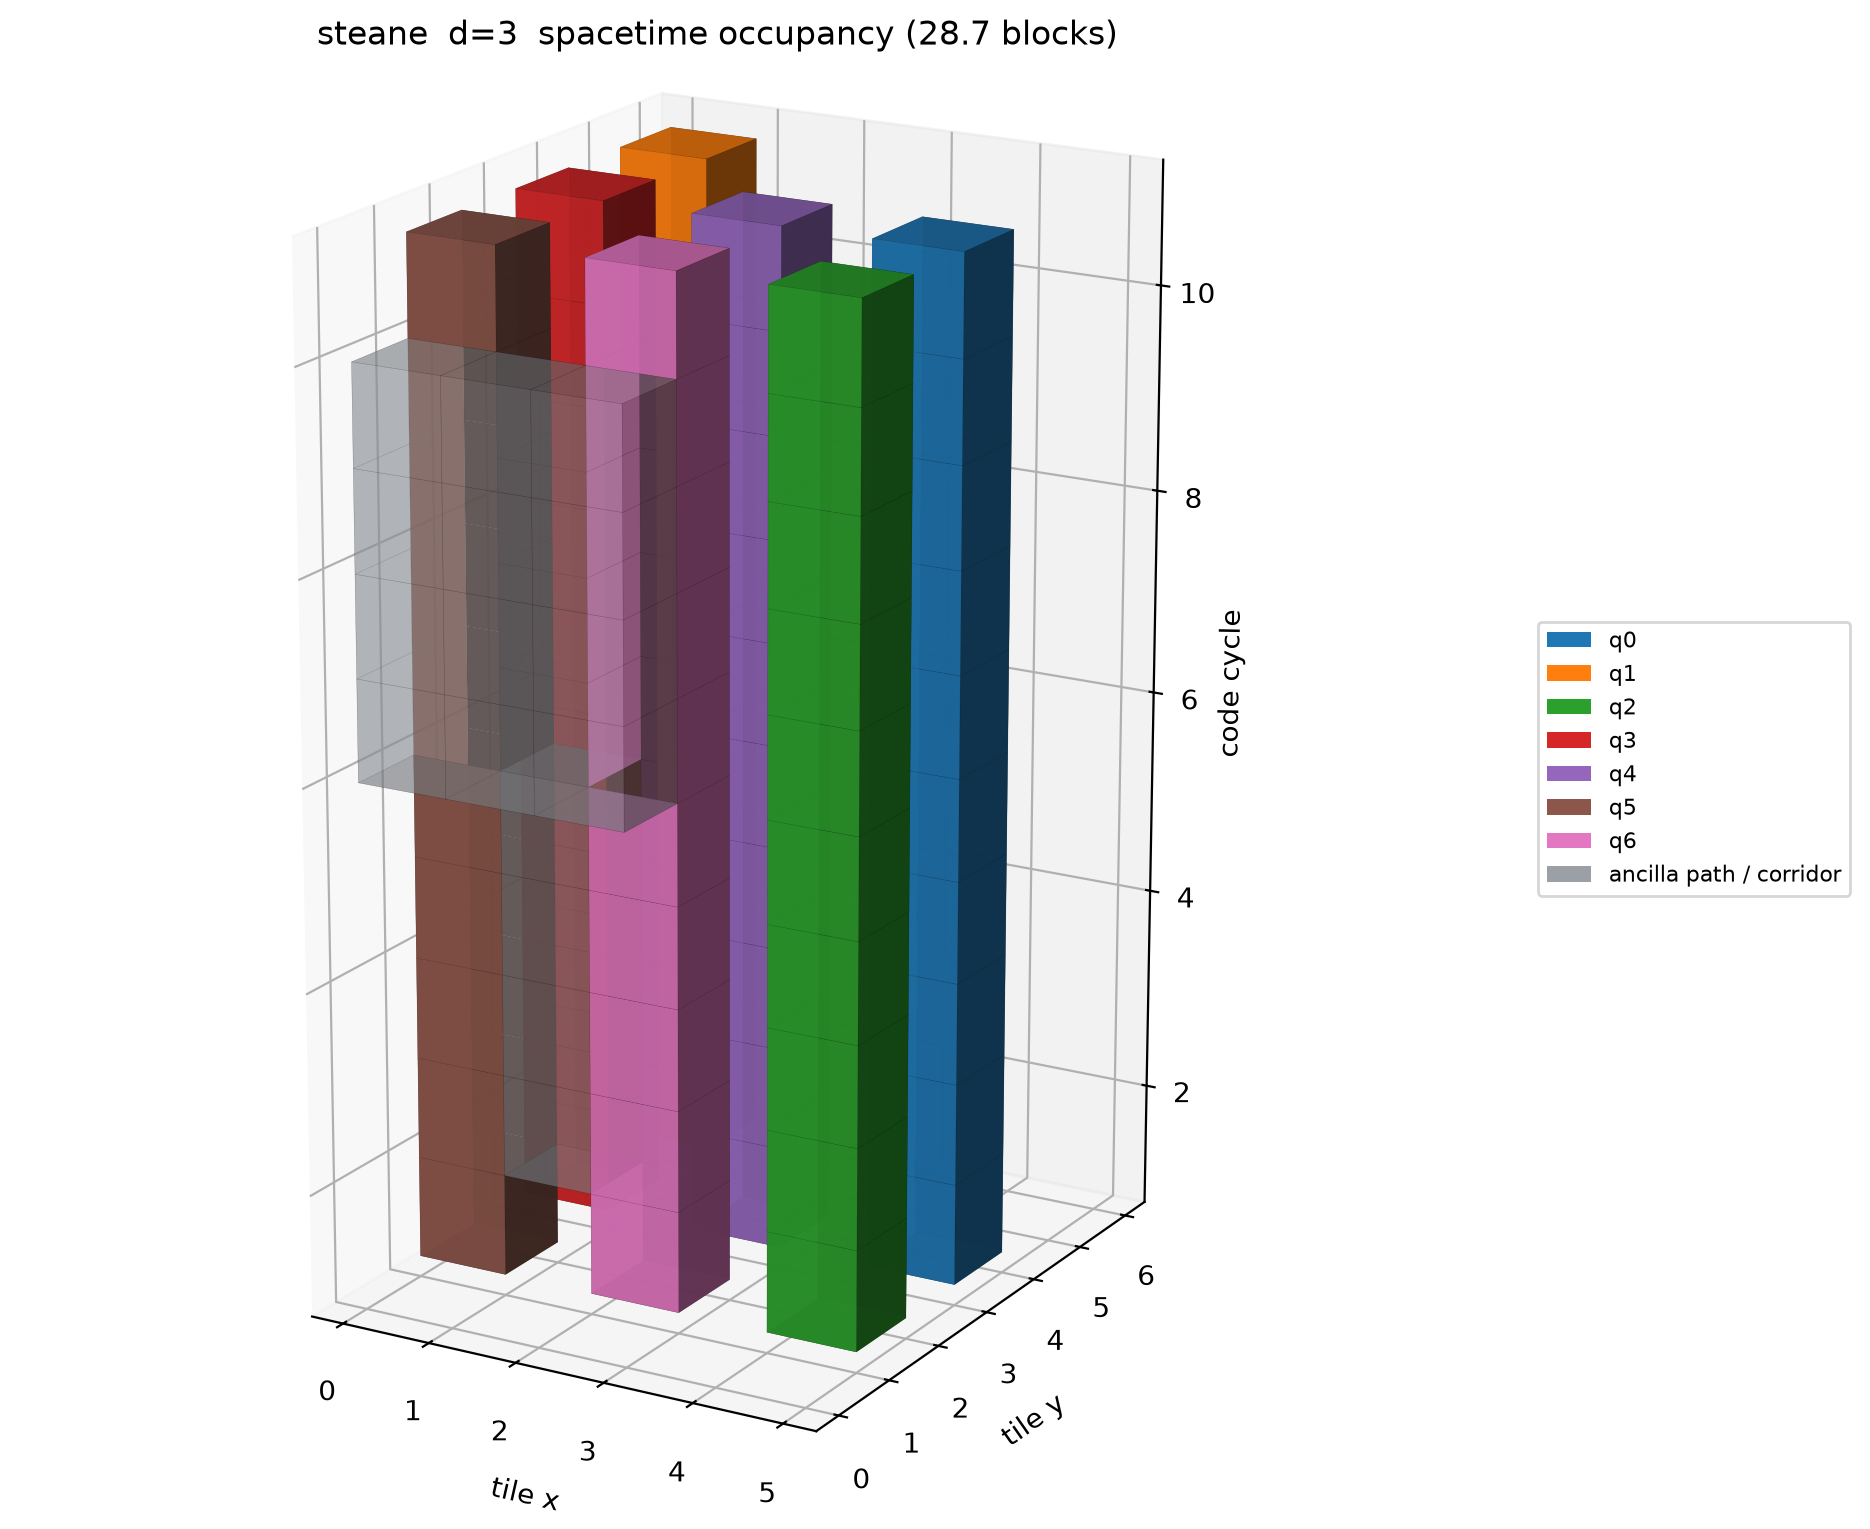

In [5]:
from circls.metrics.experiment_stats import experiment_stats
from render_spacetime import render
from nb_helpers import save_routing

print(save_routing(cp3, steps, "data/5_steane_placement_routing.json"))
stats = experiment_stats(cp3.experiment, cp3.circuit)
png, js, _ = render(stats, cp3.placement, "steane", str(HERE / "figures"), distance=3)
import shutil
shutil.move(str(HERE / "figures" / "steane_schedule.json"),
            str(HERE / "data" / "5_steane_schedule.json"))
png2 = str(HERE / "figures" / "5_steane_spacetime.png")
shutil.move(png, png2); png = png2
print("3D structure:", pathlib.Path(png).name, f"({stats.volume_blocks:.1f} blocks)")
from IPython.display import Image, display
display(Image(png, width=640))

## 6. TQEC block-graph export (rotatable)

In [6]:
import os
from export_blockgraph_auto import auto_export
auto_export(cp3, "steane", HERE / "blockgraph",
            tqec_python=os.environ.get("TQEC_PYTHON"))
BG = HERE / "blockgraph"
from IPython.display import IFrame, display
hits = sorted(BG.glob("*_blockgraph.html"))
if hits:
    print(f"-> blockgraph/{hits[0].name} -- drag to rotate "
          f"(the .dae loads into tqec / SketchUp)")
    display(IFrame("blockgraph/" + hits[0].name, width=760, height=480))
else:
    print()
    print((BG / "gap_note.txt").read_text())

wrote steane_blockstructure.json: 32 cubes, 27 pipes, 18 pinned walls, 0 Y half-cube(s), 4 layers


exported steane_blockgraph.dae/.html  (20 cubes, 18 pipes, 2 surfaces)
(full search log: blockgraph/export_log.txt)
-> blockgraph/steane_blockgraph.html -- drag to rotate (the .dae loads into tqec / SketchUp)


## 7. stim circuits: clean and noisy, d=3, 5, 7

In [7]:
from noise_inject import inject_uniform_noise
P_NOISY = 1e-3
circuits = {}
for d in (3, 5, 7):
    cp = cp3 if d == 3 else compile_d(d)
    clean = cp.circuit
    circuits[d] = clean
    (HERE / "stim" / f"d{d}").mkdir(exist_ok=True)
    pathlib.Path(f"stim/d{d}/7_steane_clean.stim").write_text(str(clean))
    pathlib.Path(f"stim/d{d}/7_steane_noisy_p1e-3.stim").write_text(
        str(inject_uniform_noise(clean, P_NOISY)))
    print(f"d={d}: {clean.num_qubits} qubits, {clean.num_detectors} detectors, "
          f"{clean.num_observables} observables")

d=3: 227 qubits, 535 detectors, 5 observables


d=5: 603 qubits, 2469 detectors, 5 observables


d=7: 1155 qubits, 6667 detectors, 5 observables


## 8. Measured logical error rate of the CircLS-compiled circuits

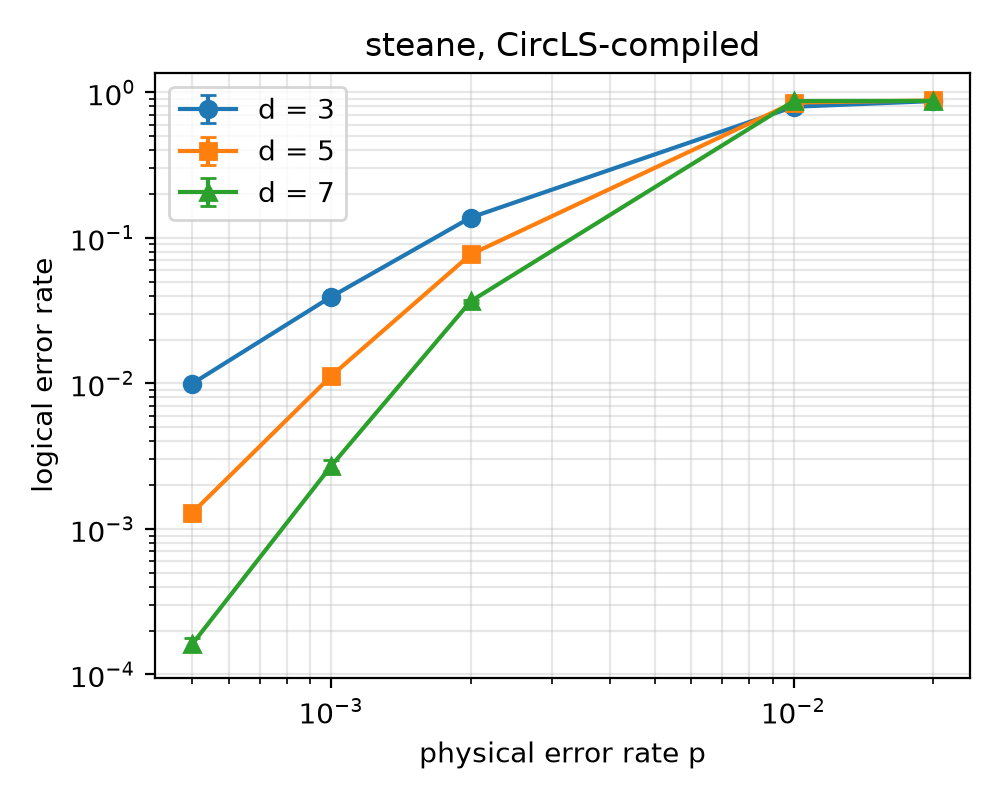

In [8]:
from ler_sampler import measure_ler
from nb_helpers import save_ler_points, plot_ler

PS = [5e-4, 1e-3, 2e-3, 1e-2, 2e-2]
WORKERS = 64     # parallel sampling processes -- set to your machine
points = {(d, p): measure_ler(inject_uniform_noise(clean, p), workers=WORKERS)
          for d, clean in circuits.items() for p in PS}
save_ler_points(points, "data/8_steane_ler_points.json")
plot_ler(points, PS, "steane, CircLS-compiled", "figures/8_steane_ler.png")
from IPython.display import Image, display
display(Image("figures/8_steane_ler.png", width=560))